# Coffee Consumption: Producing (local) vs. Non-Producing (local & re-export)

Full 1990-2019 time series, three lines:

1. **Coffee-producing — consumed locally**
2. **Non-producing — consumed locally**
3. **Non-producing — re-exported**

Data is loaded directly from Postgres (`coffee_db`) using the project's own
`get_engine()` connection helper.

## Connect to the database

Uses the `.env` config: `DATABASE_URL` if set (priority), otherwise
`DB_USER` / `DB_PASSWORD` / `DB_HOST` / `DB_PORT` / `DB_NAME`.

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, inspect
from sqlalchemy.engine import Engine
from dotenv import load_dotenv

load_dotenv()

# start psql engine to grab data from database
def get_engine() -> Engine:
    """
    Depending on .env, it will load localhost or online DB
    priority is online DB
    """
    DATABASE_URL = os.environ.get("DATABASE_URL")

    if not DATABASE_URL:
        DB_USER = os.environ.get("DB_USER")
        DB_PASSWORD = os.environ.get("DB_PASSWORD")
        DB_HOST = os.environ.get("DB_HOST", "localhost")
        DB_PORT = os.environ.get("DB_PORT", "5432")
        DB_NAME = os.environ.get("DB_NAME")

        if not all([DB_USER, DB_PASSWORD, DB_NAME]):
            raise RuntimeError(
                "Set either DATABASE_URL, or DB_USER/DB_PASSWORD/DB_NAME in .env"
            )

        DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

    else:
        DATABASE_URL = f"postgresql+psycopg2://{DATABASE_URL}"

    return create_engine(DATABASE_URL)

engine = get_engine()

insp = inspect(engine)
print("Connected. Tables found:", insp.get_table_names())

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 6)

Connected. Tables found: ['coffee_import', 'coffee_re_export', 'coffee_production', 'coffee_domestic_consumption', 'coffee_export', 'coffee_importers_consumption', 'global_co2']


## Helper: wide (year-columns) -> long (tidy) format

Tables store 1990-2019 as individual columns (`1990`, `1991`, ...). This melts
them into a tidy `country, country_code, year, value` frame.

In [7]:
YEAR_COLS = [str(y) for y in range(1990, 2020)]

def melt_years(df, value_name, id_vars=("country_code", "country")):
    """Convert a wide year-columns dataframe into tidy long format."""
    id_vars = [c for c in id_vars if c in df.columns]
    year_cols = [c for c in YEAR_COLS if c in df.columns]
    long_df = df.melt(id_vars=id_vars, value_vars=year_cols,
                       var_name="year", value_name=value_name)
    long_df["year"] = long_df["year"].astype(int)
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df

## Load the tables needed for this chart

`coffee_production` (to identify producing countries), `coffee_domestic_consumption`
(producers' own consumption), `coffee_importers_consumption` (non-producers'
consumption), `coffee_re_export` (non-producers' re-exports).

In [8]:
df_production            = pd.read_sql("SELECT * FROM coffee_production", engine)
df_domestic_consumption  = pd.read_sql("SELECT * FROM coffee_domestic_consumption", engine)
df_importers_consumption = pd.read_sql("SELECT * FROM coffee_importers_consumption", engine)
df_re_export              = pd.read_sql("SELECT * FROM coffee_re_export", engine)

producing_codes = set(df_production["country_code"].dropna().unique())

for name, df in [
    ("production", df_production),
    ("domestic_consumption", df_domestic_consumption),
    ("importers_consumption", df_importers_consumption),
    ("re_export", df_re_export),
]:
    print(f"{name:>22}: {df.shape[0]:>4} rows, {df.shape[1]:>3} cols")
print("Producing countries:", len(producing_codes))

            production:   55 rows,  34 cols
  domestic_consumption:   55 rows,  34 cols
 importers_consumption:   34 rows,  33 cols
             re_export:   34 rows,  33 cols
Producing countries: 55


## Build the three series and plot

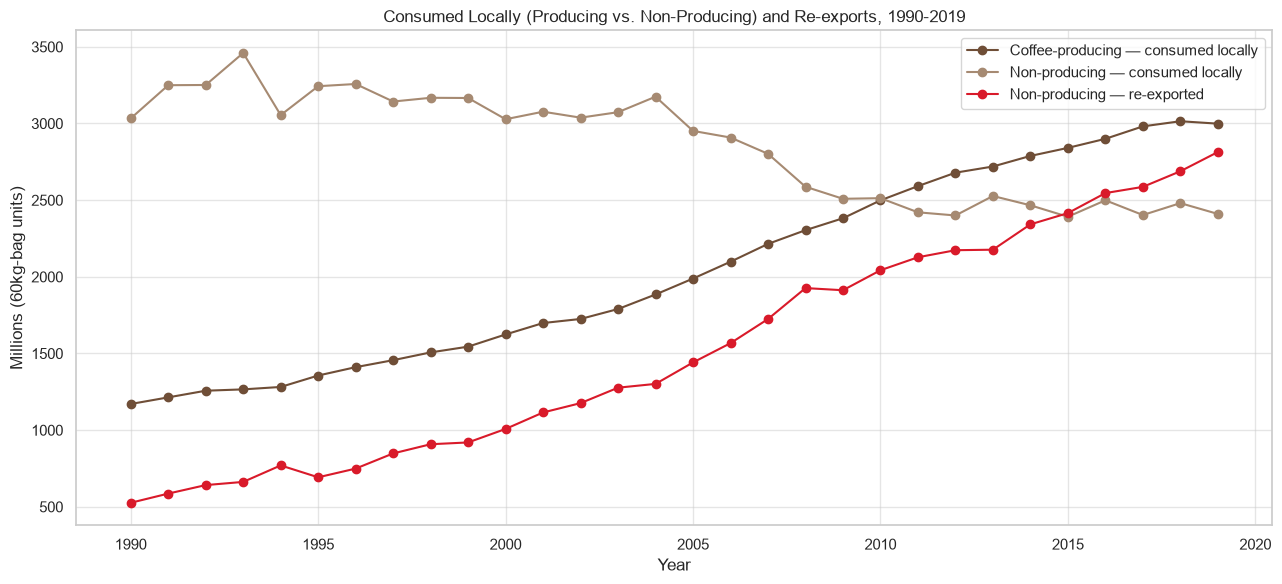

In [10]:
prod_local_by_year = (
    melt_years(df_domestic_consumption[df_domestic_consumption["country_code"].isin(producing_codes)],
               "consumption")
    .groupby("year")["consumption"].sum() / 1e6
)

nonprod_consumption_by_year = (
    melt_years(df_importers_consumption[~df_importers_consumption["country_code"].isin(producing_codes)],
               "consumption")
    .groupby("year")["consumption"].sum()
)
nonprod_reexport_by_year = (
    melt_years(df_re_export[~df_re_export["country_code"].isin(producing_codes)], "re_export")
    .groupby("year")["re_export"].sum()
)
nonprod_local_by_year = (nonprod_consumption_by_year - nonprod_reexport_by_year) / 1e6
nonprod_reexport_by_year = nonprod_reexport_by_year / 1e6

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(prod_local_by_year.index, prod_local_by_year.values, marker="o",
        label="Coffee-producing — consumed locally", color="#6f4e37")
ax.plot(nonprod_local_by_year.index, nonprod_local_by_year.values, marker="o",
        label="Non-producing — consumed locally", color="#a68a72")
ax.plot(nonprod_reexport_by_year.index, nonprod_reexport_by_year.values, marker="o",
        label="Non-producing — re-exported", color="#d91a2a")

ax.set_title("Consumed Locally (Producing vs. Non-Producing) and Re-exports, 1990-2019")
ax.set_xlabel("Year")
ax.set_ylabel("Millions (60kg-bag units)")
ax.legend()
plt.tight_layout()
plt.show()